In [1]:
import os
import re
import unicodedata

import pandas as pd

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")
val_df = pd.read_csv("../data/raw/validation.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [3]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (70000, 2)
Validation: (10000, 2)
Test: (10000, 2)


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [4]:
print("Train:")
print(train_df.isnull().sum())

print("\nValidation:")
print(val_df.isnull().sum())

print("\nTest:")
print(test_df.isnull().sum())

Train:
labels    0
text      0
dtype: int64

Validation:
labels    0
text      0
dtype: int64

Test:
labels    0
text      0
dtype: int64


In [5]:
print(
    "Empty train texts:",
    train_df["text"].astype(str).str.strip().eq("").sum()
)

print(
    "Empty validation texts:",
    val_df["text"].astype(str).str.strip().eq("").sum()
)

print(
    "Empty test texts:",
    test_df["text"].astype(str).str.strip().eq("").sum()
)

Empty train texts: 0
Empty validation texts: 0
Empty test texts: 0


In [6]:
print(
    "Duplicated rows in train:",
    train_df.duplicated().sum()
)

print(
    "Duplicated texts in train:",
    train_df["text"].duplicated().sum()
)

Duplicated rows in train: 1020
Duplicated texts in train: 1022


In [7]:
duplicated_rows = train_df[
    train_df.duplicated(keep=False)
].sort_values(by="text")

duplicated_rows.head(20)

,labels,text
13778,ar,- ولدى المجلس حاليا مشروع نشط لمعالجة معايير ا...
28542,ar,- ولدى المجلس حاليا مشروع نشط لمعالجة معايير ا...
44424,hi,1822 में शहर की अंग ् रेजी कॉलोनी के वित ् त-प...
24676,hi,1822 में शहर की अंग ् रेजी कॉलोनी के वित ् त-प...
1686,tr,"2001 ' in ikinci yarısında 183,000 ' den fazla..."
32904,tr,"2001 ' in ikinci yarısında 183,000 ' den fazla..."
8775,nl,"49 doden, 148 gewonden bij gewelddadige aanval..."
35261,nl,"49 doden, 148 gewonden bij gewelddadige aanval..."
35372,it,"49 morti, 148 feriti in violenti attacchi in Iraq"
40619,it,"49 morti, 148 feriti in violenti attacchi in Iraq"


In [8]:
text_label_counts = (
    train_df
    .groupby("text")["labels"]
    .nunique()
)

conflicting_texts = text_label_counts[
    text_label_counts > 1
]

print(
    "Số text có nhiều hơn 1 label:",
    len(conflicting_texts)
)

Số text có nhiều hơn 1 label: 2


In [9]:
conflicting_samples = train_df[
    train_df["text"].isin(
        conflicting_texts.index
    )
].sort_values(by="text")

conflicting_samples

,labels,text
51539,pt,Santorum Romping To Minnesota Victory
53666,nl,Santorum Romping To Minnesota Victory
5551,pl,Snowden Hits Hurdles in Search for Asylum
20561,nl,Snowden Hits Hurdles in Search for Asylum


In [10]:
before = len(train_df)

train_df = train_df[
    ~train_df["text"].isin(conflicting_texts.index)
].reset_index(drop=True)

after = len(train_df)

print("Trước khi xóa:", before)
print("Sau khi xóa:", after)
print("Số mẫu mâu thuẫn đã xóa:", before - after)

Trước khi xóa: 70000
Sau khi xóa: 69996
Số mẫu mâu thuẫn đã xóa: 4


In [11]:
before = len(train_df)

train_df = train_df.drop_duplicates().reset_index(drop=True)

after = len(train_df)

print("Trước khi xóa duplicate:", before)
print("Sau khi xóa duplicate:", after)
print("Số duplicate đã xóa:", before - after)

Trước khi xóa duplicate: 69996
Sau khi xóa duplicate: 68976
Số duplicate đã xóa: 1020


In [12]:
print("Duplicated rows:", train_df.duplicated().sum())
print("Duplicated texts:", train_df["text"].duplicated().sum())

text_label_counts = (
    train_df
    .groupby("text")["labels"]
    .nunique()
)

print(
    "Texts with conflicting labels:",
    (text_label_counts > 1).sum()
)

Duplicated rows: 0
Duplicated texts: 0
Texts with conflicting labels: 0


In [13]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])

train_val_overlap = train_texts.intersection(val_texts)

print(
    "Số text trùng giữa train và validation:",
    len(train_val_overlap)
)

Số text trùng giữa train và validation: 112


In [14]:
test_texts = set(test_df["text"])

train_test_overlap = train_texts.intersection(test_texts)

print(
    "Số text trùng giữa train và test:",
    len(train_test_overlap)
)

Số text trùng giữa train và test: 150


In [15]:
val_test_overlap = val_texts.intersection(test_texts)

print(
    "Số text trùng giữa validation và test:",
    len(val_test_overlap)
)

Số text trùng giữa validation và test: 31


In [17]:
conflict_train_val = []

for text in train_val_overlap:

    train_labels_for_text = set(
        train_df.loc[
            train_df["text"] == text,
            "labels"
        ]
    )

    val_labels_for_text = set(
        val_df.loc[
            val_df["text"] == text,
            "labels"
        ]
    )

    if train_labels_for_text != val_labels_for_text:
        conflict_train_val.append(
            (
                text,
                train_labels_for_text,
                val_labels_for_text
            )
        )

print(
    "Số text trùng nhưng khác label Train ↔ Validation:",
    len(conflict_train_val)
)

conflict_train_val[:10]

Số text trùng nhưng khác label Train ↔ Validation: 0


[]

In [18]:
conflict_train_test = []

for text in train_test_overlap:

    train_labels_for_text = set(
        train_df.loc[
            train_df["text"] == text,
            "labels"
        ]
    )

    test_labels_for_text = set(
        test_df.loc[
            test_df["text"] == text,
            "labels"
        ]
    )

    if train_labels_for_text != test_labels_for_text:
        conflict_train_test.append(
            (
                text,
                train_labels_for_text,
                test_labels_for_text
            )
        )

print(
    "Số text trùng nhưng khác label Train ↔ Test:",
    len(conflict_train_test)
)

conflict_train_test[:10]

Số text trùng nhưng khác label Train ↔ Test: 0


[]

In [19]:
conflict_val_test = []

for text in val_test_overlap:

    val_labels_for_text = set(
        val_df.loc[
            val_df["text"] == text,
            "labels"
        ]
    )

    test_labels_for_text = set(
        test_df.loc[
            test_df["text"] == text,
            "labels"
        ]
    )

    if val_labels_for_text != test_labels_for_text:
        conflict_val_test.append(
            (
                text,
                val_labels_for_text,
                test_labels_for_text
            )
        )

print(
    "Số text trùng nhưng khác label Validation ↔ Test:",
    len(conflict_val_test)
)

conflict_val_test[:10]

Số text trùng nhưng khác label Validation ↔ Test: 0


[]

In [20]:
before_val = len(val_df)

val_df = val_df[
    ~val_df["text"].isin(train_df["text"])
].reset_index(drop=True)

after_val = len(val_df)

print("Validation trước:", before_val)
print("Validation sau:", after_val)
print("Số mẫu đã xóa:", before_val - after_val)

Validation trước: 10000
Validation sau: 9869
Số mẫu đã xóa: 131


In [21]:
before_test = len(test_df)

test_df = test_df[
    ~test_df["text"].isin(train_df["text"])
].reset_index(drop=True)

after_test = len(test_df)

print("Test trước:", before_test)
print("Test sau:", after_test)
print("Số mẫu đã xóa:", before_test - after_test)

Test trước: 10000
Test sau: 9825
Số mẫu đã xóa: 175


In [22]:
before_test = len(test_df)

test_df = test_df[
    ~test_df["text"].isin(val_df["text"])
].reset_index(drop=True)

after_test = len(test_df)

print("Test trước:", before_test)
print("Test sau:", after_test)
print("Số mẫu đã xóa:", before_test - after_test)

Test trước: 9825
Test sau: 9813
Số mẫu đã xóa: 12


In [23]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print(
    "Train ↔ Validation:",
    len(train_texts.intersection(val_texts))
)

print(
    "Train ↔ Test:",
    len(train_texts.intersection(test_texts))
)

print(
    "Validation ↔ Test:",
    len(val_texts.intersection(test_texts))
)

Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


In [24]:
print(
    "Validation duplicated rows:",
    val_df.duplicated().sum()
)

print(
    "Validation duplicated texts:",
    val_df["text"].duplicated().sum()
)

print()

print(
    "Test duplicated rows:",
    test_df.duplicated().sum()
)

print(
    "Test duplicated texts:",
    test_df["text"].duplicated().sum()
)

Validation duplicated rows: 991
Validation duplicated texts: 991

Test duplicated rows: 641
Test duplicated texts: 641


In [25]:
val_df = val_df.drop_duplicates(
    subset=["text", "labels"]
).reset_index(drop=True)

test_df = test_df.drop_duplicates(
    subset=["text", "labels"]
).reset_index(drop=True)

In [26]:
print("Validation duplicate:", val_df.duplicated().sum())
print("Test duplicate:", test_df.duplicated().sum())

Validation duplicate: 0
Test duplicate: 0


In [27]:
import re
import html
import unicodedata


def clean_text(text):
    # Đảm bảo dữ liệu là string
    text = str(text)

    # Chuyển các HTML entities
    # Ví dụ: &amp; -> &
    text = html.unescape(text)

    # Chuẩn hóa Unicode
    text = unicodedata.normalize("NFC", text)

    # Xóa URL
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Xóa HTML tags
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Chuẩn hóa khoảng trắng
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    # Xóa khoảng trắng ở đầu/cuối
    text = text.strip()

    return text

In [28]:
sample_text = """
Hello     everyone!

Visit https://example.com

<b>This is a test.</b>
"""

print("Before:")
print(sample_text)

print("\nAfter:")
print(clean_text(sample_text))

Before:

Hello     everyone!

Visit https://example.com

<b>This is a test.</b>


After:
Hello everyone! Visit This is a test.


In [29]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [30]:
train_df[
    ["labels", "text", "clean_text"]
].head(10)

,labels,text,clean_text
0,pt,"os chefes de defesa da estónia, letónia, lituâ...","os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของ...
4,ru,Он увеличил давление .,Он увеличил давление .
5,pl,"S Jak sobie życzysz: Widzisz, jak Hitler zabij...","S Jak sobie życzysz: Widzisz, jak Hitler zabij..."
6,ur,اس کے بارے میں ، سفید شادی کی شرح کے بعد سفید ...,اس کے بارے میں ، سفید شادی کی شرح کے بعد سفید ...
7,sw,Zabuni ya ushindani pia imekuwa rahisi kwa sif...,Zabuni ya ushindani pia imekuwa rahisi kwa sif...
8,tr,Devasa 12 yüzyıl abbatiale saint-Pierre-Et-Sai...,Devasa 12 yüzyıl abbatiale saint-Pierre-Et-Sai...
9,ur,موجودہ اثاثوں میں سے ایک کا اضافہ ہو سکتا ہے ۔,موجودہ اثاثوں میں سے ایک کا اضافہ ہو سکتا ہے ۔


In [31]:
print(
    "Train empty after cleaning:",
    train_df["clean_text"].eq("").sum()
)

print(
    "Validation empty after cleaning:",
    val_df["clean_text"].eq("").sum()
)

print(
    "Test empty after cleaning:",
    test_df["clean_text"].eq("").sum()
)

Train empty after cleaning: 0
Validation empty after cleaning: 0
Test empty after cleaning: 0


In [32]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (68976, 3)
Validation: (8878, 3)
Test: (9172, 3)


In [33]:
print("Train:")
print(train_df["labels"].value_counts().sort_index())

print("\nValidation:")
print(val_df["labels"].value_counts().sort_index())

print("\nTest:")
print(test_df["labels"].value_counts().sort_index())

Train:
labels
ar    3464
bg    3464
de    3499
el    3463
en    3499
es    3498
fr    3495
hi    3464
it    3346
ja    3500
nl    3338
pl    3333
pt    3349
ru    3463
sw    3463
th    3463
tr    3464
ur    3456
vi    3464
zh    3491
Name: count, dtype: int64

Validation:
labels
ar    402
bg    402
de    500
el    402
en    499
es    500
fr    497
hi    402
it    468
ja    500
nl    463
pl    463
pt    469
ru    402
sw    402
th    402
tr    402
ur    402
vi    402
zh    499
Name: count, dtype: int64

Test:
labels
ar    440
bg    440
de    500
el    440
en    500
es    499
fr    497
hi    440
it    446
ja    500
nl    445
pl    440
pt    448
ru    440
sw    440
th    440
tr    440
ur    437
vi    440
zh    500
Name: count, dtype: int64


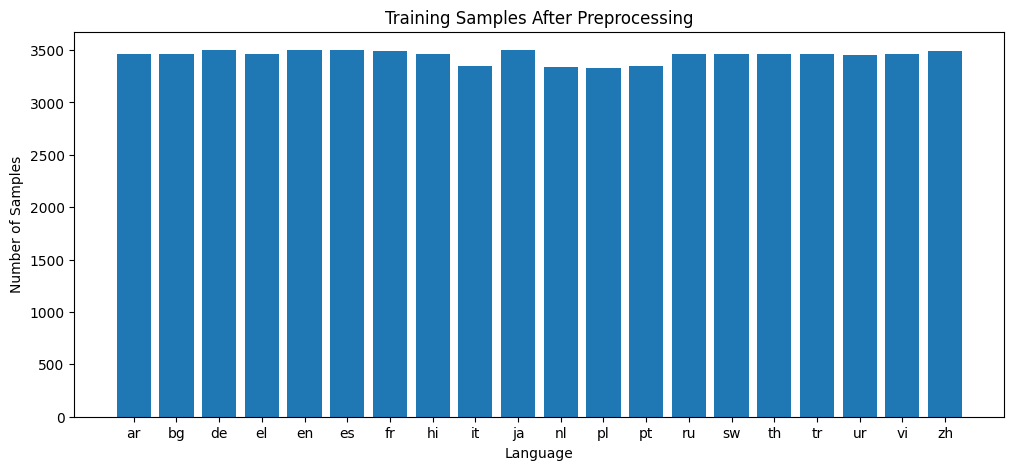

In [35]:
import matplotlib.pyplot as plt
train_counts = train_df["labels"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.bar(
    train_counts.index,
    train_counts.values
)

plt.title("Training Samples After Preprocessing")
plt.xlabel("Language")
plt.ylabel("Number of Samples")

plt.show()

In [36]:
train_processed = train_df[
    ["labels", "text", "clean_text"]
].copy()

val_processed = val_df[
    ["labels", "text", "clean_text"]
].copy()

test_processed = test_df[
    ["labels", "text", "clean_text"]
].copy()

In [37]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [38]:
train_processed.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

val_processed.to_csv(
    "../data/processed/validation_processed.csv",
    index=False
)

test_processed.to_csv(
    "../data/processed/test_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [39]:
print(os.listdir("../data/processed"))

['test_processed.csv', 'train_processed.csv', 'validation_processed.csv']


In [40]:
check_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

print(check_df.shape)
check_df.head()

(68976, 3)


,labels,text,clean_text
0,pt,"os chefes de defesa da estónia, letónia, lituâ...","os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของ...
4,ru,Он увеличил давление .,Он увеличил давление .


## Kết luận

- Dữ liệu được kiểm tra và loại bỏ các mẫu trùng lặp trong tập huấn luyện.
- Các mẫu có cùng nội dung văn bản nhưng mang nhãn ngôn ngữ khác nhau đã được loại bỏ để giảm nhiễu dữ liệu.
- Các mẫu bị trùng giữa tập train, validation và test đã được xử lý nhằm hạn chế hiện tượng rò rỉ dữ liệu (data leakage).
- Văn bản được chuẩn hóa Unicode, loại bỏ URL, thẻ HTML và chuẩn hóa khoảng trắng.
- Các ký tự đặc trưng của từng ngôn ngữ, bao gồm dấu tiếng Việt và các hệ chữ như tiếng Nhật, tiếng Trung và tiếng Thái, được giữ nguyên.
- Không có văn bản rỗng sau quá trình tiền xử lý.
- Dữ liệu sau tiền xử lý được lưu trong thư mục `data/processed` để sử dụng cho bước trích xuất đặc trưng và xây dựng mô hình.